# 01 Data Ingestion and EDA

This notebook loads cafeteria transaction data and performs quick exploratory analysis.

**Input file:** `backend/notebooks/data/transactions.csv`

**Goals:**
- Validate schema and nulls
- Understand distributions and trends
- Save quick profiling outputs

In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

In [ ]:
BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "data" / "transactions.csv"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("Exists:", DATA_PATH.exists())

DATA_PATH: S:\cafeteria\cafeteria-iq\backend\notebooks\data\transactions.csv
Exists: True


In [ ]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (1000, 10)


,transaction_id,customer_id,customer_age,customer_gender,date,day_of_week,time_slot,total_amount,payment_method,items_json
0,TXN-2024-0000001,CUST1001,38,M,2024-01-07 19:17:00,Sun,Lunch,34,Cash,"[{""itemName"":""Lassi"",""quantity"":1,""price"":30,""..."
1,TXN-2024-0000002,CUST1002,36,F,2024-01-09 08:05:00,Tue,Lunch,142,Cash,"[{""itemName"":""Tea"",""quantity"":1,""price"":15,""ca..."
2,TXN-2024-0000003,CUST1003,42,M,2024-06-27 14:21:00,Thu,Lunch,105,Wallet,"[{""itemName"":""Veg Biryani"",""quantity"":1,""price..."
3,TXN-2024-0000004,CUST1004,21,F,2024-03-29 17:16:00,Fri,Dinner,85,UPI,"[{""itemName"":""Maggi"",""quantity"":1,""price"":40,""..."
4,TXN-2024-0000005,CUST1005,36,M,2024-06-29 09:02:00,Sat,Snacks,205,Wallet,"[{""itemName"":""Cold Coffee"",""quantity"":2,""price..."


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   transaction_id   1000 non-null   str  
 1   customer_id      1000 non-null   str  
 2   customer_age     1000 non-null   int64
 3   customer_gender  1000 non-null   str  
 4   date             1000 non-null   str  
 5   day_of_week      1000 non-null   str  
 6   time_slot        1000 non-null   str  
 7   total_amount     1000 non-null   int64
 8   payment_method   1000 non-null   str  
 9   items_json       1000 non-null   str  
dtypes: int64(2), str(8)
memory usage: 78.3 KB


In [ ]:
nulls = df.isna().sum().sort_values(ascending=False)
nulls[nulls > 0].head(30)

Series([], dtype: int64)

In [ ]:
# Basic standardization for common fields
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
elif "transaction_ts" in df.columns:
    df["date"] = pd.to_datetime(df["transaction_ts"], errors="coerce")

if "day_of_week" not in df.columns and "date" in df.columns:
    df["day_of_week"] = df["date"].dt.day_name().str[:3]

if "total_amount" in df.columns:
    df["total_amount"] = pd.to_numeric(df["total_amount"], errors="coerce")

if "transaction_id" in df.columns:
    before = len(df)
    df = df.drop_duplicates(subset=["transaction_id"]) 
    print("Dropped duplicate transaction_id rows:", before - len(df))

df = df.dropna(subset=["customer_id", "total_amount"], how="any")
print("Post-cleaning shape:", df.shape)
df.head()

Dropped duplicate transaction_id rows: 0
Post-cleaning shape: (1000, 10)


,transaction_id,customer_id,customer_age,customer_gender,date,day_of_week,time_slot,total_amount,payment_method,items_json
0,TXN-2024-0000001,CUST1001,38,M,2024-01-07 19:17:00,Sun,Lunch,34,Cash,"[{""itemName"":""Lassi"",""quantity"":1,""price"":30,""..."
1,TXN-2024-0000002,CUST1002,36,F,2024-01-09 08:05:00,Tue,Lunch,142,Cash,"[{""itemName"":""Tea"",""quantity"":1,""price"":15,""ca..."
2,TXN-2024-0000003,CUST1003,42,M,2024-06-27 14:21:00,Thu,Lunch,105,Wallet,"[{""itemName"":""Veg Biryani"",""quantity"":1,""price..."
3,TXN-2024-0000004,CUST1004,21,F,2024-03-29 17:16:00,Fri,Dinner,85,UPI,"[{""itemName"":""Maggi"",""quantity"":1,""price"":40,""..."
4,TXN-2024-0000005,CUST1005,36,M,2024-06-29 09:02:00,Sat,Snacks,205,Wallet,"[{""itemName"":""Cold Coffee"",""quantity"":2,""price..."


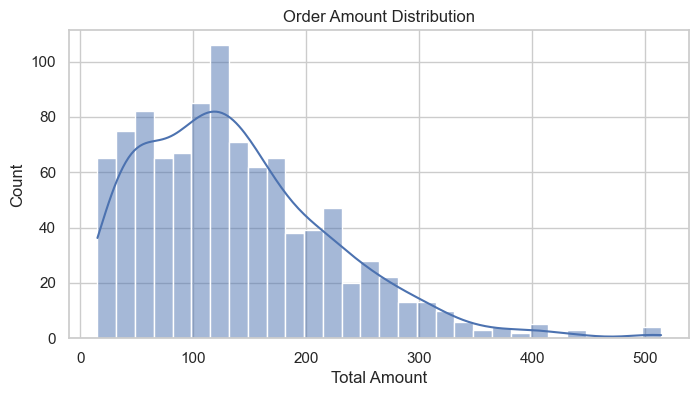

In [ ]:
# Distribution: total amount
if "total_amount" in df.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df["total_amount"].dropna(), bins=30, kde=True)
    plt.title("Order Amount Distribution")
    plt.xlabel("Total Amount")
    plt.show()

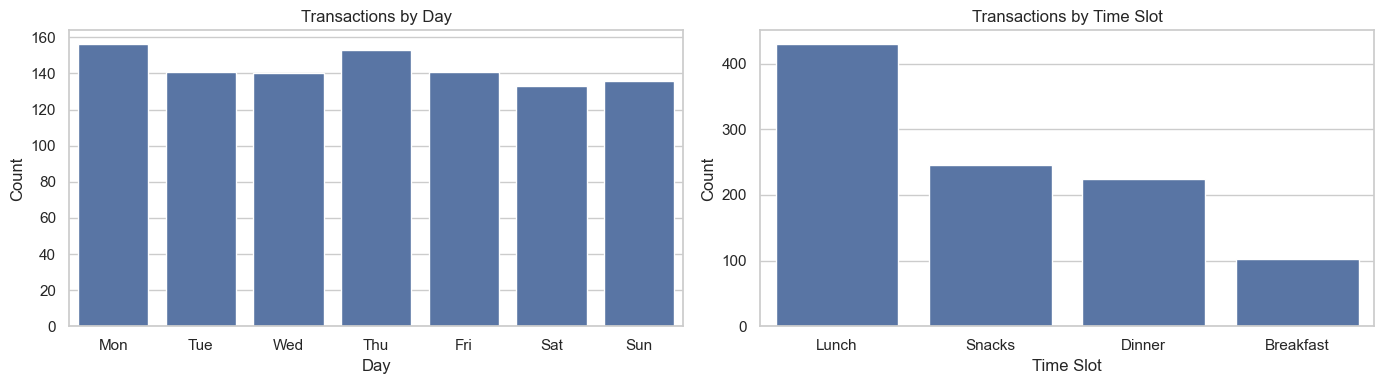

In [ ]:
# Day-of-week and time-slot trend
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

if "day_of_week" in df.columns:
    order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    day_counts = df["day_of_week"].value_counts().reindex(order).fillna(0)
    sns.barplot(x=day_counts.index, y=day_counts.values, ax=axes[0])
    axes[0].set_title("Transactions by Day")
    axes[0].set_xlabel("Day")
    axes[0].set_ylabel("Count")

if "time_slot" in df.columns:
    slot_counts = df["time_slot"].astype(str).value_counts()
    sns.barplot(x=slot_counts.index, y=slot_counts.values, ax=axes[1])
    axes[1].set_title("Transactions by Time Slot")
    axes[1].set_xlabel("Time Slot")
    axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

,item,qty
0,Brownie,149
11,Maggi,144
10,Lemonade,141
8,Ice Cream,140
9,Lassi,138
17,Veg Biryani,134
2,Chicken Curry+Rice,133
13,Rajma Chawal,132
15,Sandwich,131
7,Fruit Bowl,130


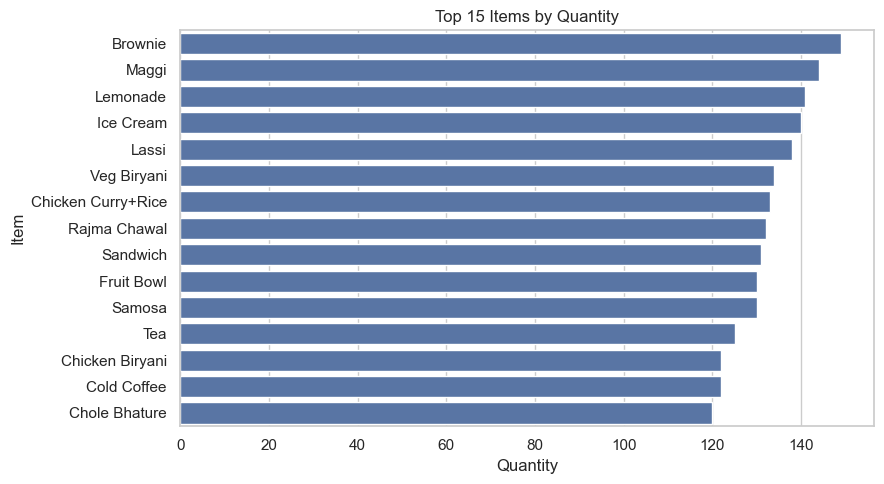

In [ ]:
# Optional: inspect item popularity if items_json exists
if "items_json" in df.columns:
    item_rows = []
    for _, row in df[["transaction_id", "items_json"]].dropna().iterrows():
        try:
            raw = row["items_json"]
            items = json.loads(raw) if isinstance(raw, str) else raw
            for it in items:
                if isinstance(it, dict):
                    nm = it.get("itemName") or it.get("name")
                    qty = it.get("quantity", 1)
                    if nm:
                        item_rows.append((nm, qty))
                elif isinstance(it, str):
                    item_rows.append((it, 1))
        except Exception:
            continue

    item_df = pd.DataFrame(item_rows, columns=["item", "qty"])
    top_items = item_df.groupby("item", as_index=False)["qty"].sum().sort_values("qty", ascending=False).head(15)
    display(top_items)

    plt.figure(figsize=(9,5))
    sns.barplot(data=top_items, x="qty", y="item")
    plt.title("Top 15 Items by Quantity")
    plt.xlabel("Quantity")
    plt.ylabel("Item")
    plt.tight_layout()
    plt.show()
else:
    print("items_json column not found, skipping item-level EDA.")

In [ ]:
# Save cleaned copy for next notebooks
clean_path = OUTPUT_DIR / "transactions_cleaned.csv"
df.to_csv(clean_path, index=False)
print("Saved cleaned dataset:", clean_path)

Saved cleaned dataset: S:\cafeteria\cafeteria-iq\backend\notebooks\outputs\transactions_cleaned.csv


## Next Notebook

Proceed to `02_preprocessing_and_feature_engineering.ipynb` where you will:
- build customer-level features (RFM + behavior ratios),
- scale features,
- and prepare training matrix for clustering.